In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [26]:
def watts_strogatz_adjacency(n, k, p, seed=None):
    if k % 2 != 0:
        raise ValueError("k must be even")

    rng = np.random.default_rng(seed)

    A = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(1, k // 2 + 1):
            neighbor = (i + j) % n
            A[i, neighbor] = 1
            A[neighbor, i] = 1

    for i in range(n):
        for j in range(1, k // 2 + 1):
            neighbor = (i + j) % n

            if rng.random() < p:
                A[i, neighbor] = 0
                A[neighbor, i] = 0

                possible = list(set(range(n)) - {i} - set(np.where(A[i] == 1)[0]))
                new_neighbor = rng.choice(possible)

                A[i, new_neighbor] = 1
                A[new_neighbor, i] = 1

    return A

def laplacian_from_adjacency(A):
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A
    return L

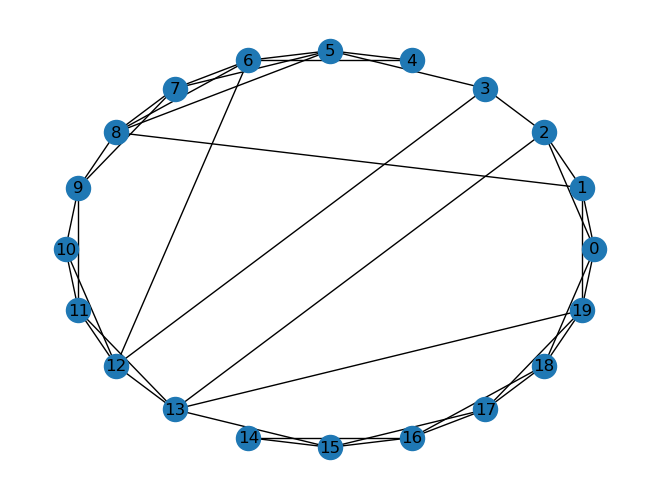

In [ ]:
A = watts_strogatz_adjacency(n=20, k=4, p=0.2, seed=2)
G = nx.from_numpy_array(A)
pos = nx.circular_layout(G)

plt.figure()
nx.draw(G, pos, with_labels=True)
plt.show()

In [36]:
L = laplacian_from_adjacency(A)

eigvals, eigvecs = np.linalg.eigh(L)

W = np.diag(eigvals)
U = eigvecs.T

u_2 = U[1]

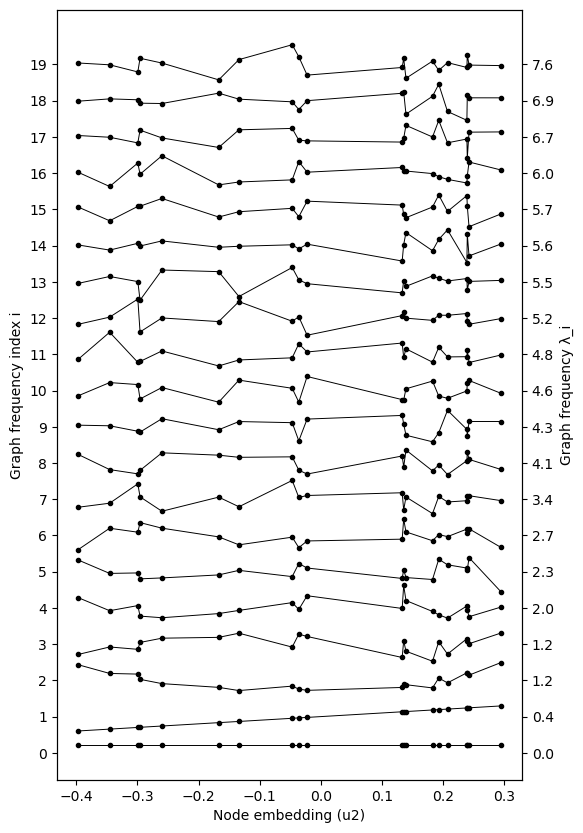

In [ ]:
ordering = np.argsort(u_2)

U_reordered = U[:, ordering]

x = u_2[ordering]

def watts_strogatz_adjacency(n, k, p, seed=None):
    if k % 2 != 0:
        raise ValueError("k must be even")
    rng = np.random.default_rng(seed)
    A = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(1, k // 2 + 1):
            neighbor = (i + j) % n
            A[i, neighbor] = 1
            A[neighbor, i] = 1

    for i in range(n):
        for j in range(1, k // 2 + 1):
            neighbor = (i + j) % n
            if rng.random() < p:
                A[i, neighbor] = 0
                A[neighbor, i] = 0
                possible = list(set(range(n)) - {i} - set(np.where(A[i] == 1)[0]))
                new_neighbor = rng.choice(possible)
                A[i, new_neighbor] = 1
                A[new_neighbor, i] = 1

    return A

def laplacian_from_adjacency(A):
    return np.diag(A.sum(axis=1)) - A

A = watts_strogatz_adjacency(n=20, k=4, p=0.2, seed=2)
L = laplacian_from_adjacency(A)

eigvals, eigvecs = np.linalg.eigh(L)
U = eigvecs.T

u_2 = U[1]
ordering = np.argsort(u_2)

U_reordered = U[:, ordering]
x = u_2[ordering]

plt.figure(figsize=(6, 10))  # taller figure

for i in range(U_reordered.shape[0]):
    y = U_reordered[i] + i
    plt.plot(x, y, linewidth=0.7, marker='o', markersize=3, color='black')
    

plt.xlabel("Node embedding (u2)")
plt.ylabel("Graph frequency index i")

ax = plt.gca()
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

ticks = np.arange(len(eigvals))
ax.set_yticks(ticks)
ax2.set_yticks(ticks)
ax2.set_yticklabels([f"{eigvals[i]:.1f}" for i in ticks])

ax2.set_ylabel("Graph frequency λ_i")

plt.show()